In [33]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
  return 3*x**2 - 4*x + 5

In [3]:
f(3.0)

20.0

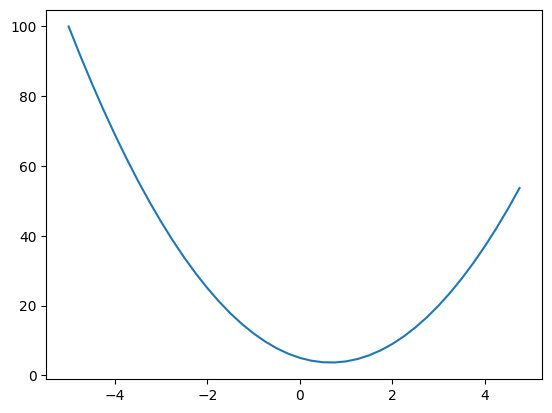

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [5]:
h = 0.00000000000001
# x = 3.0
x = 2/3

(f(x + h) - f(x))/h

0.0

In [6]:
a = 2.0
b = -3.0
c = 10.0

d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h )

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [52]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supports int/float powers"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * self.data**(other-1) * out.grad
        
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1

    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out
    
    def backward(self):
    
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    



In [9]:
a = Value(2.0)

b = Value(3.0)

a / b

Value(data=0.6666666666666666)

In [10]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [11]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{  %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

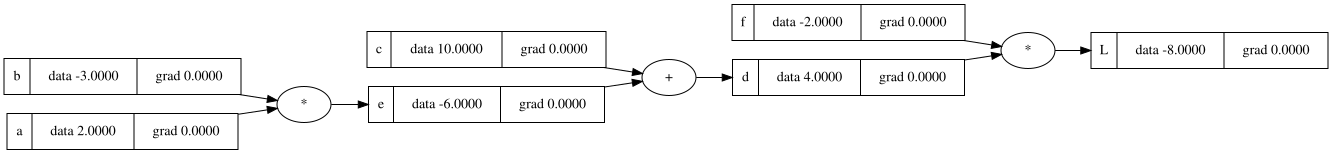

In [12]:
draw_dot(L)

In [13]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad


e = a*b
d = e + c
L = d * f

print(L.data)

-8.0


In [14]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2-L1)/h)


lol()

-1.9999999999953388


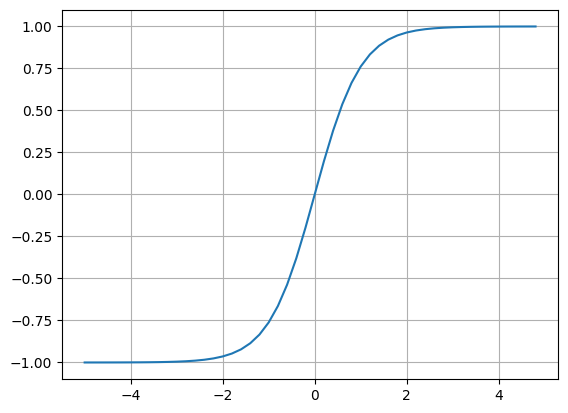

In [15]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [16]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()
# draw_dot(o)

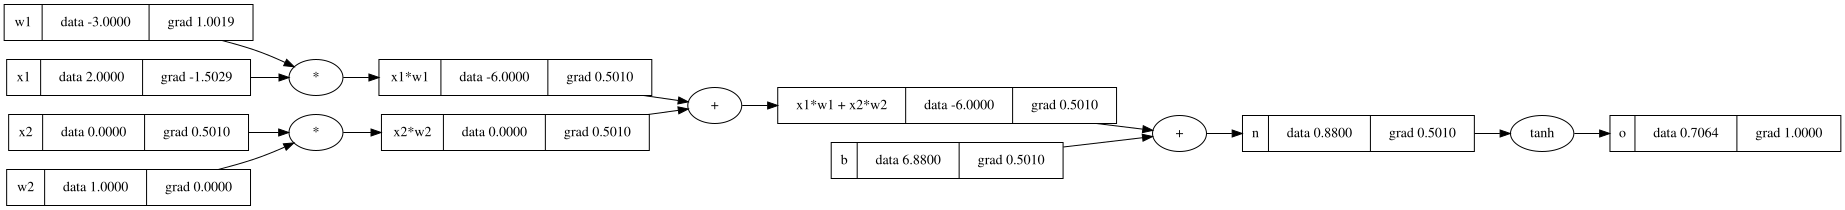

In [17]:
draw_dot(o)

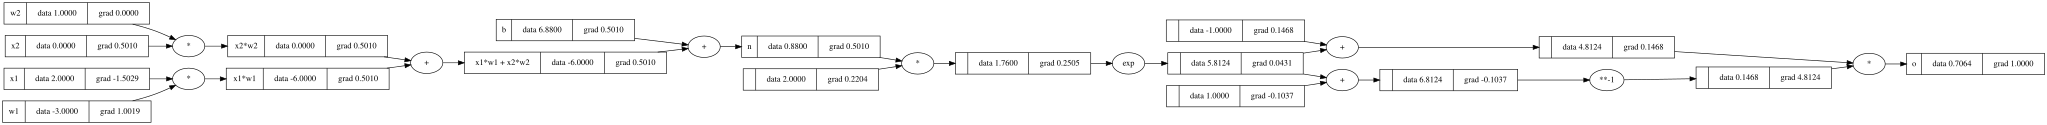

In [18]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'


e = (2*n).exp()
o = (e - 1)/(e + 1)

o.label = 'o'
o.backward()
draw_dot(o)

In [19]:

o.backward()

In [20]:
topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[Value(data=2),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.88),
 Value(data=0.8799999999999999),
 Value(data=1.7599999999999998),
 Value(data=5.812437394402587),
 Value(data=-1),
 Value(data=4.812437394402587),
 Value(data=1),
 Value(data=6.812437394402587),
 Value(data=0.14679033980138242),
 Value(data=0.7064193203972352)]

In [21]:


o.grad = 1.0

In [22]:



o._backward()

In [23]:
n._backward()

In [24]:
x1w1x2w2._backward()

In [25]:
x1w1._backward()
x2w2._backward()

In [26]:
o.grad = 1.0


# 1 - tanh(x)**2

1 - o.data**2

n.grad =0.5
x1w1x2w2.grad = 0.5
b.grad=0.5
x1w1.grad=0.5
x2w2.grad=.5

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [27]:
import torch

x1 = torch.Tensor([2.0]).double()                               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                               ; w2.requires_grad = True
b = torch.Tensor([6.88]).double()                               ; b.requires_grad = True

n = w1*x1 + w2*x2 + b

o = torch.tanh(n)

print(o.data.item())
o.backward()

print('w1', w1.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('x2', x2.grad.item())



0.7064193777288968
w1 1.0019433255382364
w2 0.0
x1 -1.5029149883073547
x2 0.5009716627691182


In [28]:
torch.Tensor([[1,2,3],[4,5,6]])

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [127]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

# what is x?
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]   

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



In [133]:
x = [2.0, 3.0, -1]
n = MLP(3, [4, 4, 1])

n(x)

Value(data=0.9695483543320574)

In [134]:
n.parameters()

[Value(data=-0.6328791252720278),
 Value(data=0.49681037503478076),
 Value(data=-0.4241436855539573),
 Value(data=0.7435540702618166),
 Value(data=-0.8549958959887543),
 Value(data=-0.23445408974738213),
 Value(data=0.6936349747903989),
 Value(data=-0.9523911573750719),
 Value(data=-0.2507798518635824),
 Value(data=0.8822969512365535),
 Value(data=0.5284648161421828),
 Value(data=0.17471714610968014),
 Value(data=-0.017581971179437605),
 Value(data=0.20033143936005082),
 Value(data=-0.34722528760950944),
 Value(data=0.9767961920785462),
 Value(data=0.7123402491846671),
 Value(data=-0.24198321717878746),
 Value(data=0.9790038134993613),
 Value(data=-0.21392240474173385),
 Value(data=-0.9907998085285776),
 Value(data=0.8859864681683096),
 Value(data=0.30912055745234834),
 Value(data=0.23105134758449286),
 Value(data=0.30697824330278767),
 Value(data=0.891702357048807),
 Value(data=0.06256950466282252),
 Value(data=-0.5024771007504341),
 Value(data=-0.9254170363766807),
 Value(data=-0.756

In [135]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]



In [ ]:

for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    
    #back pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 7.2010754046392424
1 6.083206132779042
2 2.7264906025554
3 1.8551634400174781
4 3.015209189866607
5 1.7085081793382617
6 0.1021790474621936
7 0.007329784409226234
8 0.0015351940581514083
9 0.0004622355796913256
10 0.0001557565290590533
11 5.526339599735848e-05
12 2.045048116639948e-05
13 7.950176760398658e-06
14 3.2931140206634478e-06
15 1.4774960890517634e-06
16 7.278108807069305e-07
17 3.957744399405575e-07
18 2.3645899325058778e-07
19 1.533165051482019e-07


In [136]:
ypred

[Value(data=0.9999423874062172),
 Value(data=-0.9999882959325432),
 Value(data=-0.9996171932221082),
 Value(data=0.9999423868088814)]

In [119]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.0009587539935611874)

In [117]:
loss.backward()

In [65]:
n.layers[0].neurons[0].w[0].grad

0.008072679730330906

In [118]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [77]:
n.layers[0].neurons[0].w[0].data

0.8030274025690693

In [120]:

ypred

[Value(data=0.9993891442821313),
 Value(data=-0.9814268501784361),
 Value(data=-0.9752419574946337),
 Value(data=0.999323031860903)]

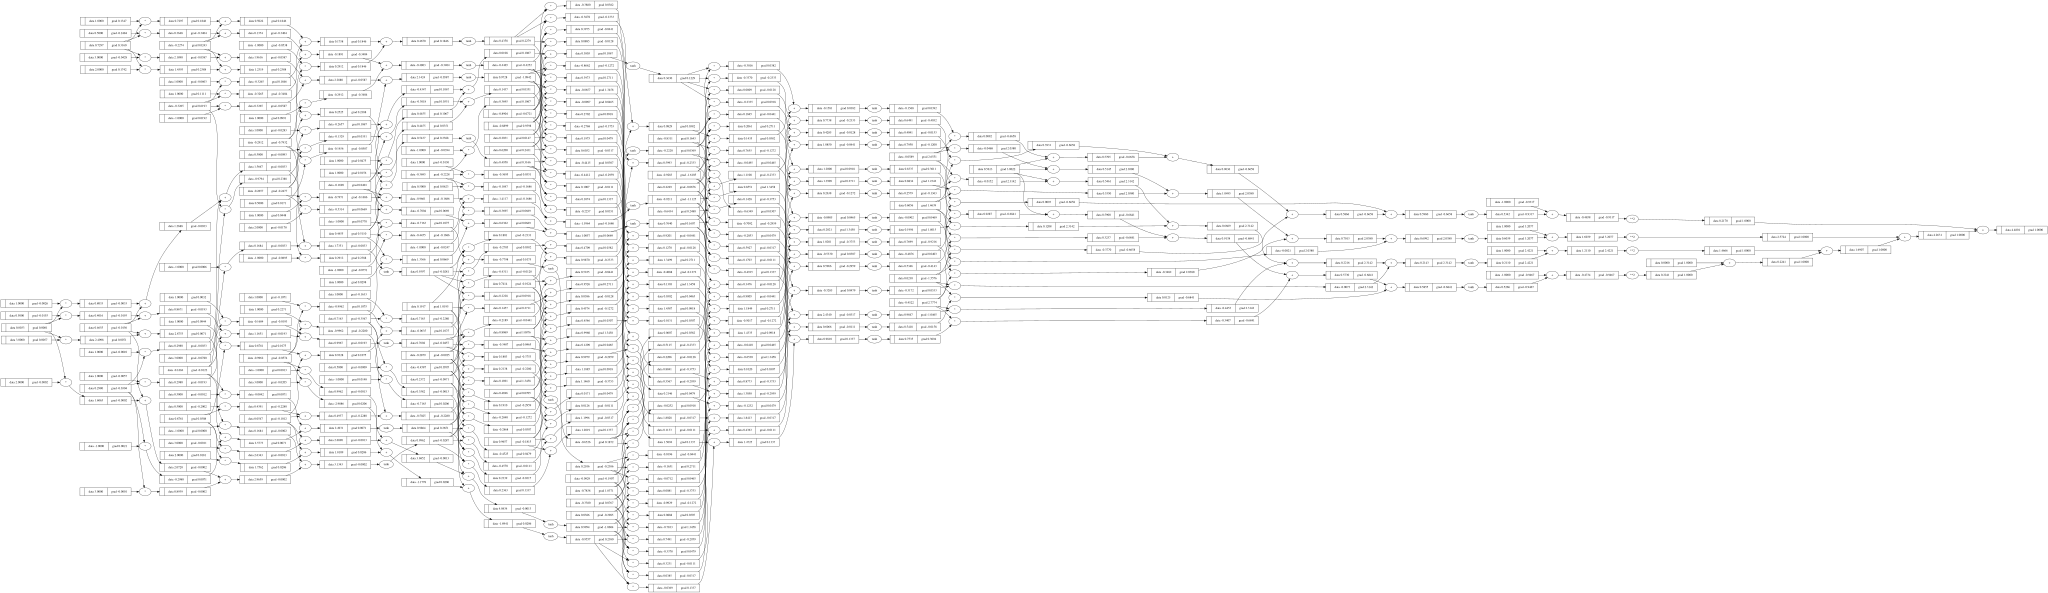

In [66]:
draw_dot(loss)

-0.005886802137581481